In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


# Import Libraries


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from plotly.offline import init_notebook_mode, iplot  
init_notebook_mode(connected=True)

import warnings
warnings.filterwarnings('ignore')

# Load Data 

In [3]:
df=pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe(include='all')

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

In [7]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [9]:
df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

### Class Distribution

The dataset is highly imbalanced.

- Class 0 (Normal Transactions): 284,315 (99.83%)
- Class 1 (Fraud Transactions): 492 (0.17%)

This means that fraudulent transactions are extremely rare compared to normal transactions.

#  Amount Distribution

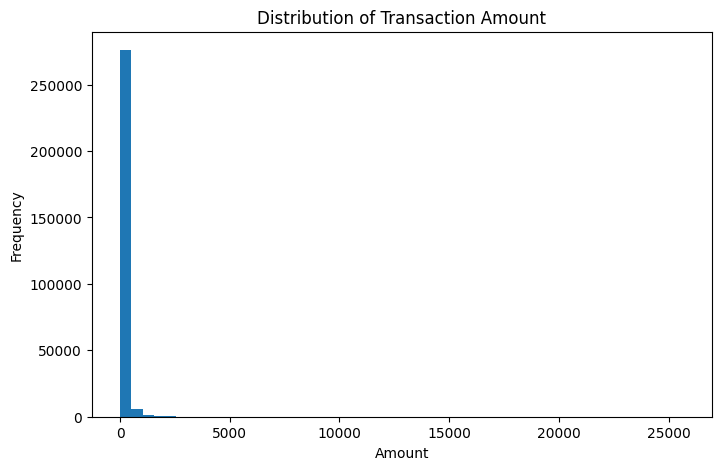

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df['Amount'], bins=50)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Time Distribution

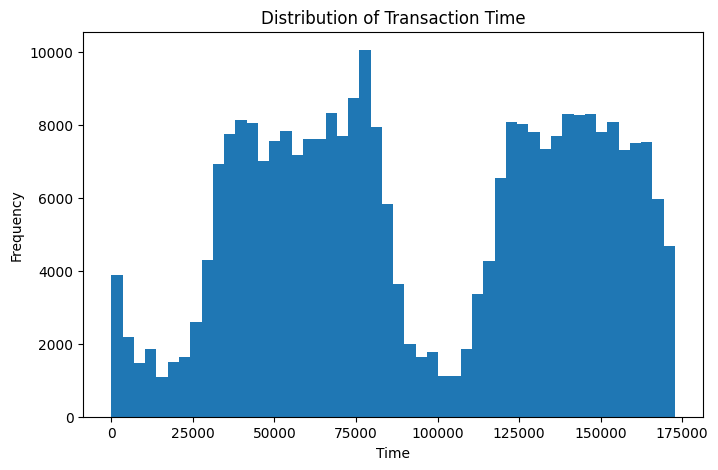

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df['Time'], bins=50)
plt.title("Distribution of Transaction Time")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

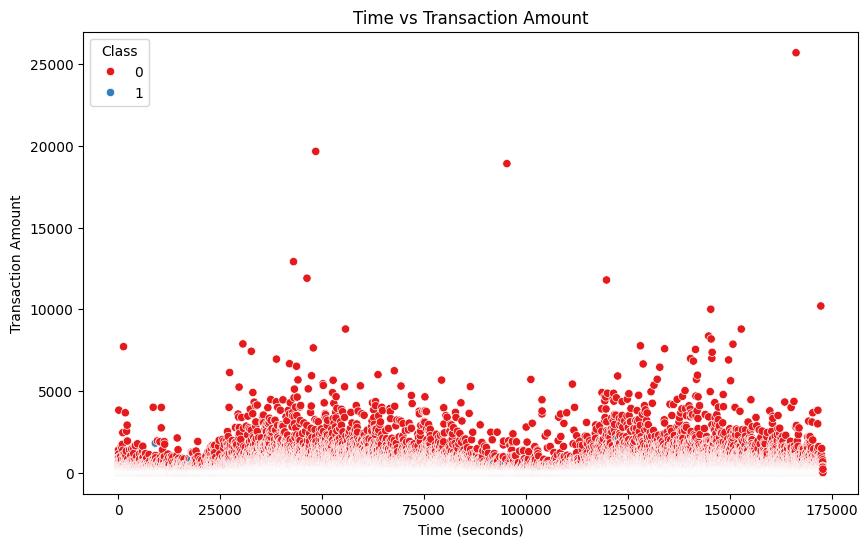

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Time', y='Amount', hue='Class', palette='Set1')
plt.title('Time vs Transaction Amount')
plt.xlabel('Time (seconds)')
plt.ylabel('Transaction Amount')
plt.show()

# Correlation

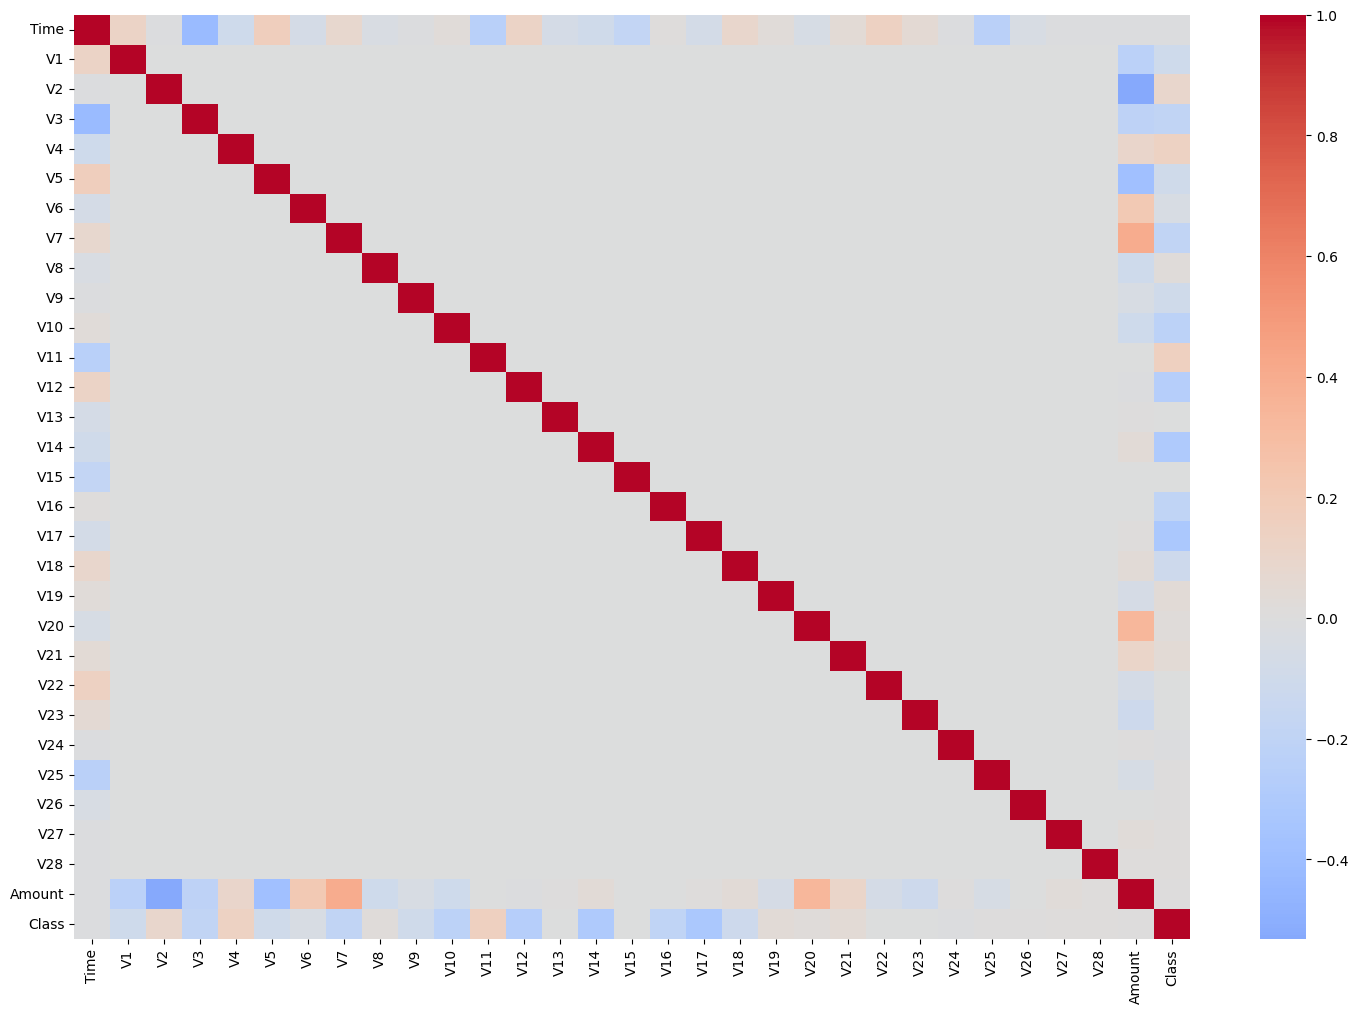

In [13]:
plt.figure(figsize=(18,12))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.show()

In [14]:
corr = df.corr()['Class'].sort_values(ascending=False)
print(corr)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


### Correlation Analysis

The strongest positive correlations with the target are V11, V4, and V2.

The strongest negative correlations are V17, V14, V12, and V10.

The Amount and Time features have very weak correlations with the target, indicating that they are not strong individual predictors of fraudulent transactions.

In [15]:
X = df.drop('Class', axis=1)
y = df['Class']

In [16]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [18]:
model = LogisticRegression(max_iter=1000, random_state=42)

In [19]:
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [20]:
y_pred = model.predict(x_test)

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9991397773954567
Precision: 0.8266666666666667
Recall   : 0.6326530612244898
F1 Score : 0.7167630057803468


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[56851    13]
 [   36    62]]


In [24]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    x_train,
    y_train,
    cv=5,
    scoring='f1'
)

print(scores)
print("Mean:", scores.mean())
print("STD :", scores.std())

[0.70229008 0.69117647 0.75177305 0.75555556 0.73529412]
Mean: 0.7272178539544235
STD : 0.026044517329517396


# **Logistic Regression

## Model Description

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. It predicts the probability that an observation belongs to one of two classes.

---

## Model Performance

| Metric | Value |
|--------|-------|
| Accuracy | 99.91% |
| Precision | 82.67% |
| Recall | 63.27% |
| F1-Score | 71.68% |
| Cross Validation Mean (F1) | 72.72% |
| Cross Validation STD | 0.026 |

---

## Analysis

- The model achieved a very high Accuracy (99.91%). However, Accuracy is not a reliable metric because the dataset is highly imbalanced.
- Precision is high (82.67%), meaning that most transactions predicted as fraud were actually fraudulent.
- Recall is relatively low (63.27%), indicating that the model failed to detect some fraudulent transactions.
- The F1-Score (71.68%) shows a reasonable balance between Precision and Recall.
- Cross-validation produced a mean F1-score of 72.72% with a standard deviation of 0.026, indicating stable model performance and no clear signs of overfitting.


# RandomForest

In [25]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [26]:
rf_model.fit(x_train,y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [27]:
y_pred=rf_model.predict(x_test)

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9995962220427653
Precision: 0.9411764705882353
Recall   : 0.8163265306122449
F1 Score : 0.8743169398907104


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [30]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[56859     5]
 [   18    80]]


# Logistic Regression + Smote

In [31]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [32]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [33]:
lr_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_smote.fit(x_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [34]:
y_pred = lr_smote.predict(x_test)

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9741055440469084
Precision: 0.057803468208092484
Recall   : 0.9183673469387755
F1 Score : 0.10876132930513595


In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [37]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[55397  1467]
 [    8    90]]


# # Random Forest + Smote

In [38]:
from imblearn.over_sampling import SMOTE

In [39]:
smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [40]:
print(y_train.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64


In [41]:
print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [42]:
from sklearn.ensemble import RandomForestClassifier

# Create & Train Model

In [43]:
x_train.shape

(227845, 30)

In [44]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(x_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

# prediction

In [45]:
y_pred = rf_model.predict(x_test)

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9995962220427653
Precision: 0.9411764705882353
Recall   : 0.8163265306122449
F1 Score : 0.8743169398907104
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

[[56859     5]
 [   18    80]]


# xgboost

In [47]:
from xgboost import XGBClassifier

In [48]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

In [49]:
xgb_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [50]:
y_pred = xgb_model.predict(x_test)

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9994908886626171
Precision: 0.9156626506024096
Recall   : 0.7755102040816326
F1 Score : 0.8397790055248618


In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.78      0.84        98

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [53]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[56857     7]
 [   22    76]]


# Model Comparison

To identify the most suitable model for credit card fraud detection, four different approaches were evaluated using Accuracy, Precision, Recall, and F1-Score.

| Model | Accuracy | Precision | Recall | F1 Score |
|--------|----------|-----------|--------|----------|
| Logistic Regression | 99.91% | 82.67% | 63.27% | 71.68% |
| Logistic Regression + SMOTE | 97.41% | 5.78% | **91.84%** | 10.88% |
| Random Forest | **99.96%** | **94.12%** | **81.63%** | **87.43%** |
| XGBoost | 99.95% | 91.57% | 77.55% | 83.98% |

## Model Analysis

- **Logistic Regression** provided a strong baseline model with excellent Accuracy, but its Recall was relatively low, meaning many fraudulent transactions were missed.

- **Logistic Regression + SMOTE** significantly improved Recall by detecting more fraud cases. However, this came at the cost of a very low Precision, producing a large number of false positive predictions. As a result, the overall F1-Score decreased substantially.

- **XGBoost** achieved excellent classification performance and outperformed Logistic Regression in all major metrics. It provided high Precision and a balanced Recall, making it a strong candidate for fraud detection.

- **Random Forest** delivered the best overall performance among all tested models. It achieved the highest Accuracy, Precision, Recall, and F1-Score, providing the best balance between detecting fraudulent transactions and minimizing false alarms.

## Final Model Selection

Based on the experimental results, **Random Forest** was selected as the final model for this project because it achieved the highest overall performance.

### Final Performance of Random Forest

- **Accuracy:** 99.96%
- **Precision:** 94.12%
- **Recall:** 81.63%
- **F1-Score:** 87.43%

The Random Forest model demonstrated the best trade-off between identifying fraudulent transactions and reducing false positives, making it the most reliable model for this credit card fraud detection task.

In [54]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [55]:
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

In [56]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Randomized Search

In [57]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=3,
    cv=3,
    scoring='f1',
    random_state=42,
    verbose=2,
    n_jobs=-1
)

In [58]:
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 3.5min
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time= 7.7min
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 3.5min
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 7.8min


RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=3, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 200]},
                   random_state=42, scoring='f1', verbose=2)

# Best Parameters 

In [59]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}


# Best CV F1 Score

In [60]:
print("Best CV F1 Score:")
print(random_search.best_score_)

Best CV F1 Score:
0.8351148569993555


In [61]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(x_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9995962220427653
Precision: 0.9411764705882353
Recall   : 0.8163265306122449
F1 Score : 0.8743169398907104


# Final Insights

This project aimed to build an effective machine learning model for detecting fraudulent credit card transactions using a highly imbalanced dataset.

## Key Findings

- The dataset is highly imbalanced, with fraudulent transactions representing less than **0.2%** of the total observations.
- Exploratory Data Analysis (EDA) showed that most PCA-transformed features have weak linear correlations with the target class, while **V17, V14, V12, V10, and V16** exhibited the strongest relationships with fraudulent transactions.
- The **Amount** feature contained several outliers, which were expected due to the nature of fraud detection. These outliers were retained because they may represent important fraudulent activities.
- Multiple machine learning models were evaluated to identify the most suitable classifier for this problem.

## Model Performance Summary

| Model | F1 Score |
|--------|----------|
| Logistic Regression | 71.68% |
| Logistic Regression + SMOTE | 10.88% |
| Random Forest | **87.43%** |
| XGBoost | 83.98% |
| LightGBM | Lower than Random Forest |

## Final Model Selection

Among all evaluated models, **Random Forest** achieved the best overall performance.

### Final Performance

- **Accuracy:** 99.96%
- **Precision:** 94.12%
- **Recall:** 81.63%
- **F1-Score:** 87.43%

Random Forest provided the best balance between detecting fraudulent transactions and minimizing false alarms, making it the most reliable model for this dataset.

## Conclusion

This project demonstrates that traditional ensemble learning methods can achieve outstanding performance on highly imbalanced fraud detection datasets. Although techniques such as SMOTE significantly increased Recall, they introduced a large number of false positives, resulting in poor Precision and F1-Score.

After comparing several machine learning algorithms and performing hyperparameter tuning, **Random Forest remained the best-performing model**. It successfully balanced Precision and Recall while maintaining excellent overall classification performance.

This model can serve as a strong baseline for real-world credit card fraud detection systems and can be further improved by incorporating additional features, advanced ensemble methods, or deep learning techniques.